In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


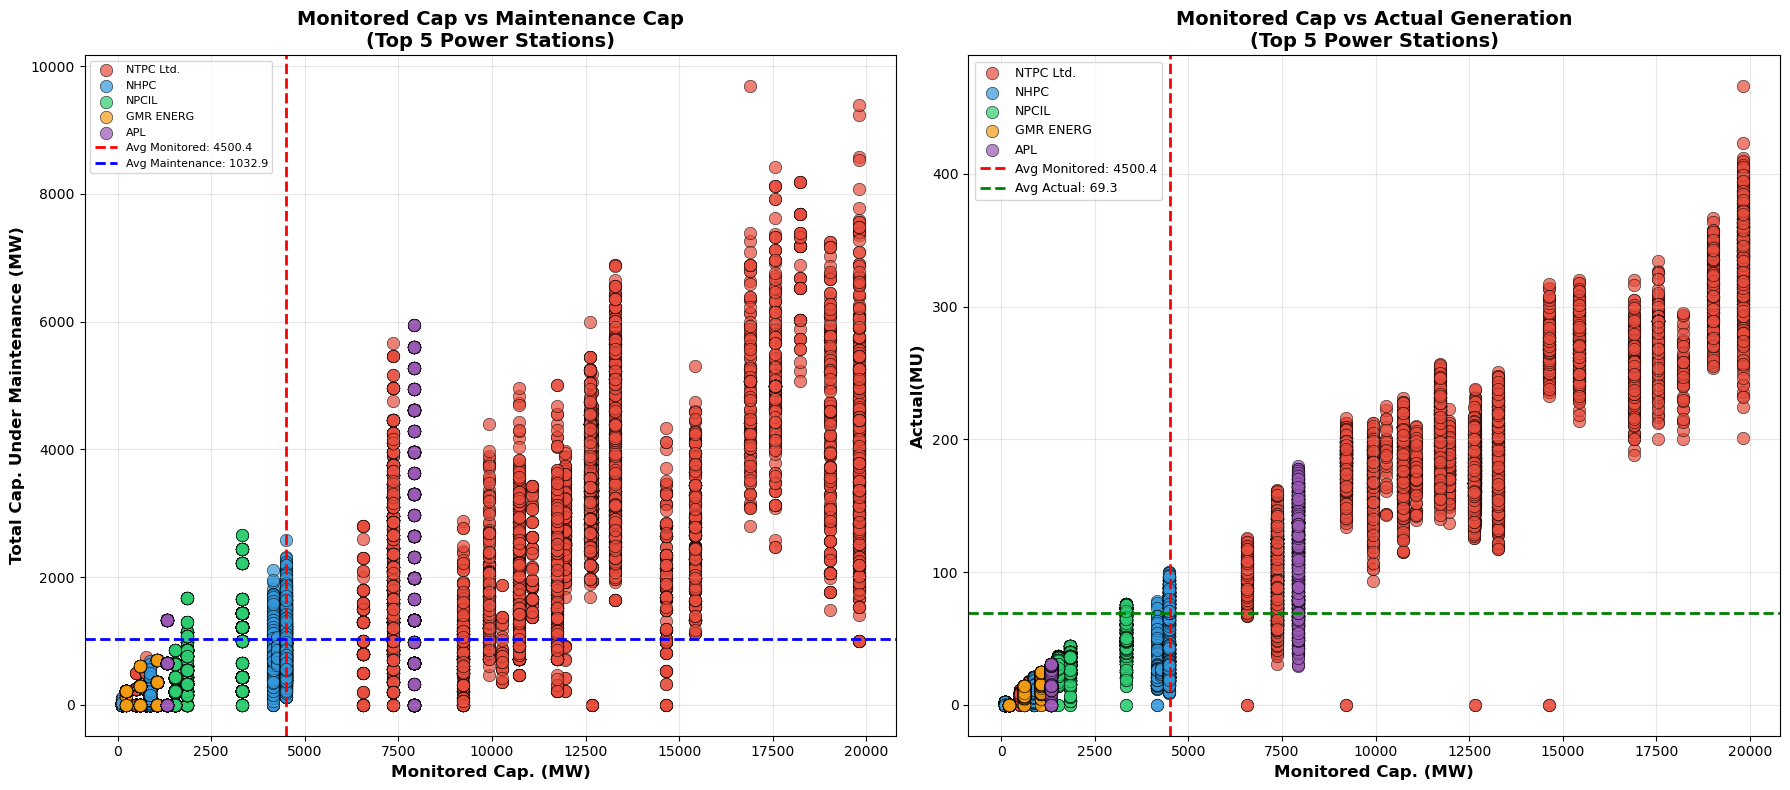

In [62]:
df = pd.read_csv('PowerGeneration - PowerGeneration (1).csv')

# Get top 5 most frequent power stations
top5 = df['Power Station'].value_counts().head(5).index.tolist()

# Filter data for top 5 stations
df_top5 = df[df['Power Station'].isin(top5)].copy()

# Calculate averages
avg_monitored = df_top5['Monitored Cap.(MW)'].mean()
avg_maintenance = df_top5['Total Cap. Under Maintenace (MW)'].mean()
avg_actual = df_top5['Actual(MU)'].mean()

# Colors for each station
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
color_map = dict(zip(top5, colors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# PLOT 1: Monitored Cap vs Total Cap Under Maintenance
for station in top5:
    data = df_top5[df_top5['Power Station'] == station]
    ax1.scatter(data['Monitored Cap.(MW)'],data['Total Cap. Under Maintenace (MW)'],c=color_map[station],label=station,s=80,alpha=0.7,edgecolors='black',linewidth=0.5)

# Average lines
ax1.axvline(avg_monitored, color='red', linestyle='--', linewidth=2, label=f'Avg Monitored: {avg_monitored:.1f}')
ax1.axhline(avg_maintenance, color='blue', linestyle='--', linewidth=2, label=f'Avg Maintenance: {avg_maintenance:.1f}')

ax1.set_xlabel('Monitored Cap. (MW)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Cap. Under Maintenance (MW)', fontsize=12, fontweight='bold')
ax1.set_title('Monitored Cap vs Maintenance Cap\n(Top 5 Power Stations)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# PLOT 2: Monitored Cap vs Actual(MU)
for station in top5:
    data = df_top5[df_top5['Power Station'] == station]
    ax2.scatter(data['Monitored Cap.(MW)'],data['Actual(MU)'],c=color_map[station],label=station,s=80,alpha=0.7,edgecolors='black',linewidth=0.5)
    
# Average lines
ax2.axvline(avg_monitored, color='red', linestyle='--', linewidth=2, label=f'Avg Monitored: {avg_monitored:.1f}')
ax2.axhline(avg_actual, color='green', linestyle='--', linewidth=2, label=f'Avg Actual: {avg_actual:.1f}')

ax2.set_xlabel('Monitored Cap. (MW)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Actual(MU)', fontsize=12, fontweight='bold')
ax2.set_title('Monitored Cap vs Actual Generation\n(Top 5 Power Stations)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_station_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

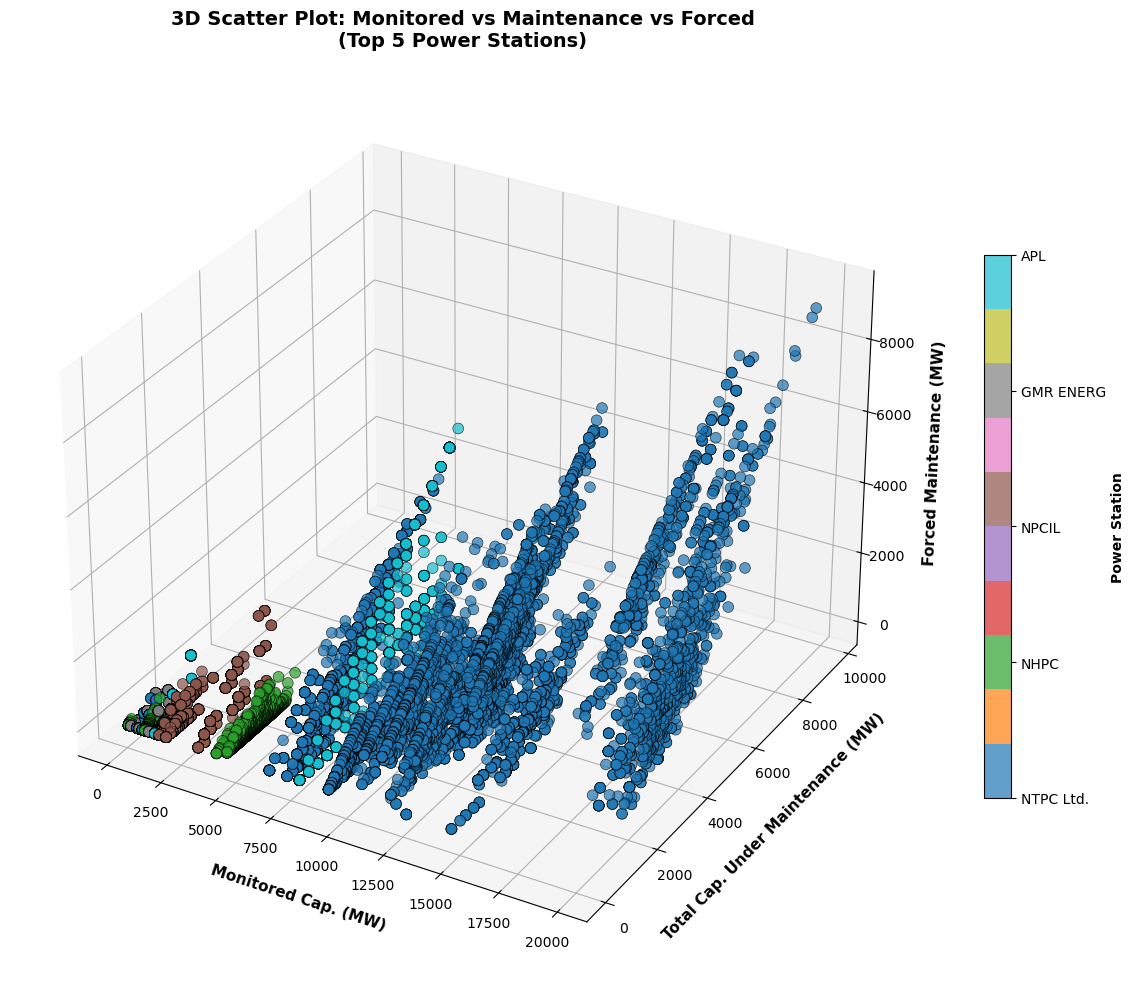

In [88]:

# Map station names to numbers (0, 1, 2, 3, 4)
station_map = {station: i for i, station in enumerate(top5)}
df_top5['station_code'] = df_top5['Power Station'].map(station_map)

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Single scatter call — no loop needed
scatter = ax.scatter(df_top5['Monitored Cap.(MW)'],df_top5['Total Cap. Under Maintenace (MW)'],df_top5['Forced Maintanence(MW)'],c=df_top5['station_code'],cmap='tab10',s=60,alpha=0.7,edgecolors='black',linewidth=0.5)

# Colorbar with station names
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_ticks(range(len(top5)))
cbar.set_ticklabels(top5)
cbar.set_label('Power Station', fontsize=10, fontweight='bold')

ax.set_xlabel('Monitored Cap. (MW)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Total Cap. Under Maintenance (MW)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_zlabel('Forced Maintenance (MW)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title('3D Scatter Plot: Monitored vs Maintenance vs Forced\n(Top 5 Power Stations)', fontsize=14, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3d_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

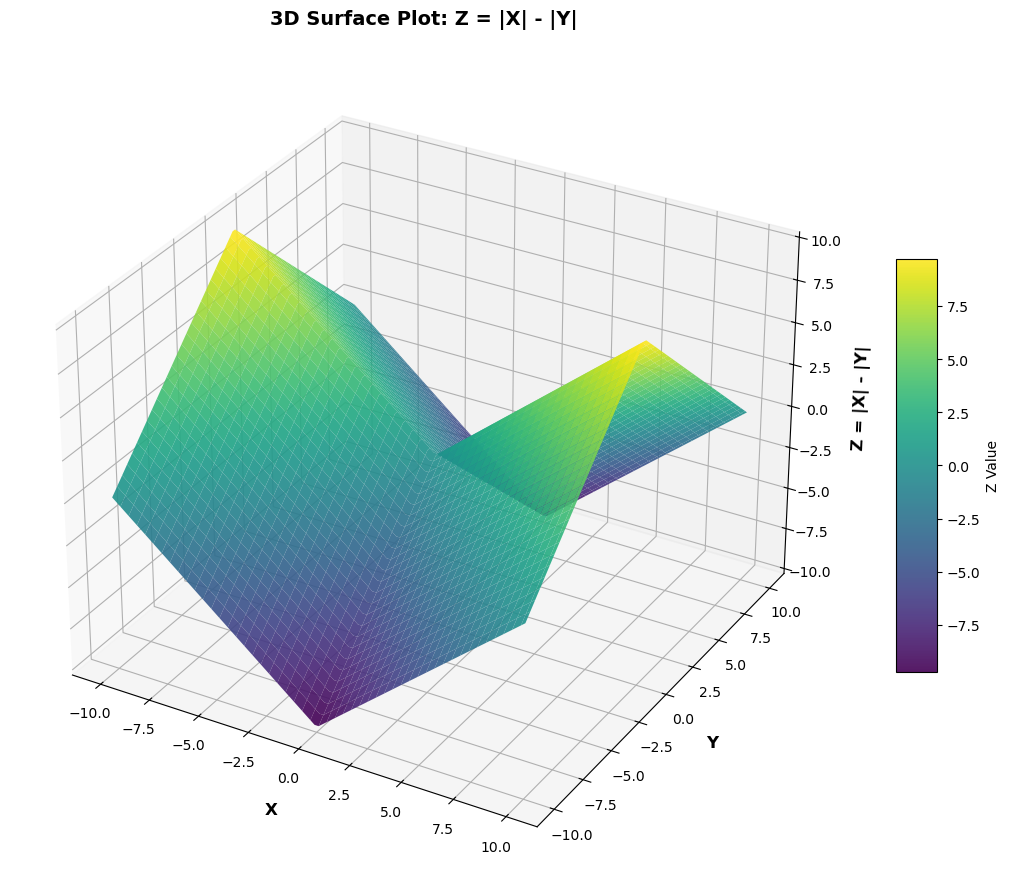

In [89]:

# Create grid of x and y values
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)

# Calculate Z = |x| - |y|
Z = np.abs(X) - np.abs(Y)

# Create 3D surface plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with colormap
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, edgecolor='none')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Z Value')

# Labels and title
ax.set_xlabel('X', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Y', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Z = |X| - |Y|', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('3D Surface Plot: Z = |X| - |Y|', fontsize=14, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3d_surface_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

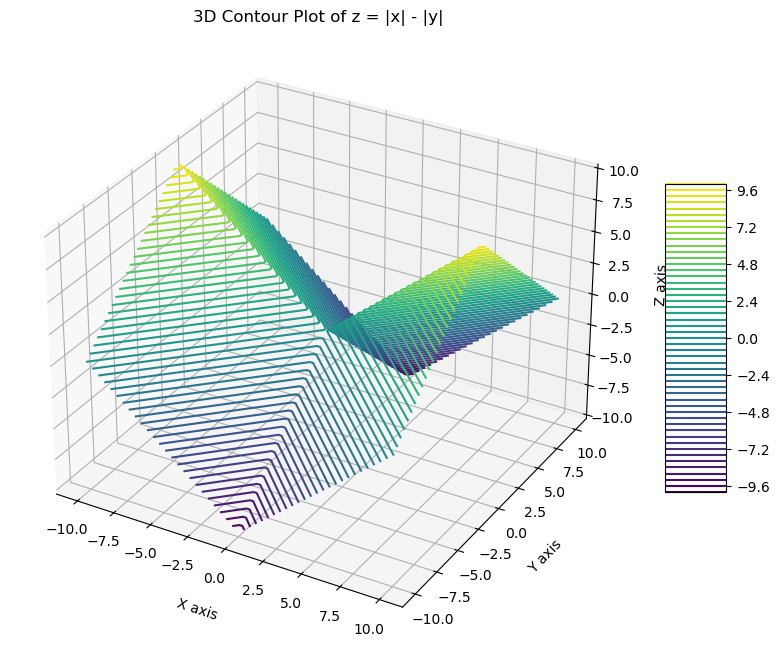

In [98]:

# Create grid of x and y values
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)

# Calculate Z = |x| - |y|
Z = np.abs(X) - np.abs(Y)

# 3. Create the 3D figure and axes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the 3D contour
contour = ax.contour3D(X, Y, Z, 50, cmap='viridis')

# 5. Customize the plot
ax.set_xlabel('X axis', labelpad=10)
ax.set_ylabel('Y axis', labelpad=10)
ax.set_zlabel('Z axis', labelpad=10)
ax.set_title('3D Contour Plot of z = |x| - |y|')

# Add a colorbar to interpret Z values
fig.colorbar(contour, shrink=0.5, aspect=5)

plt.show()   

### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

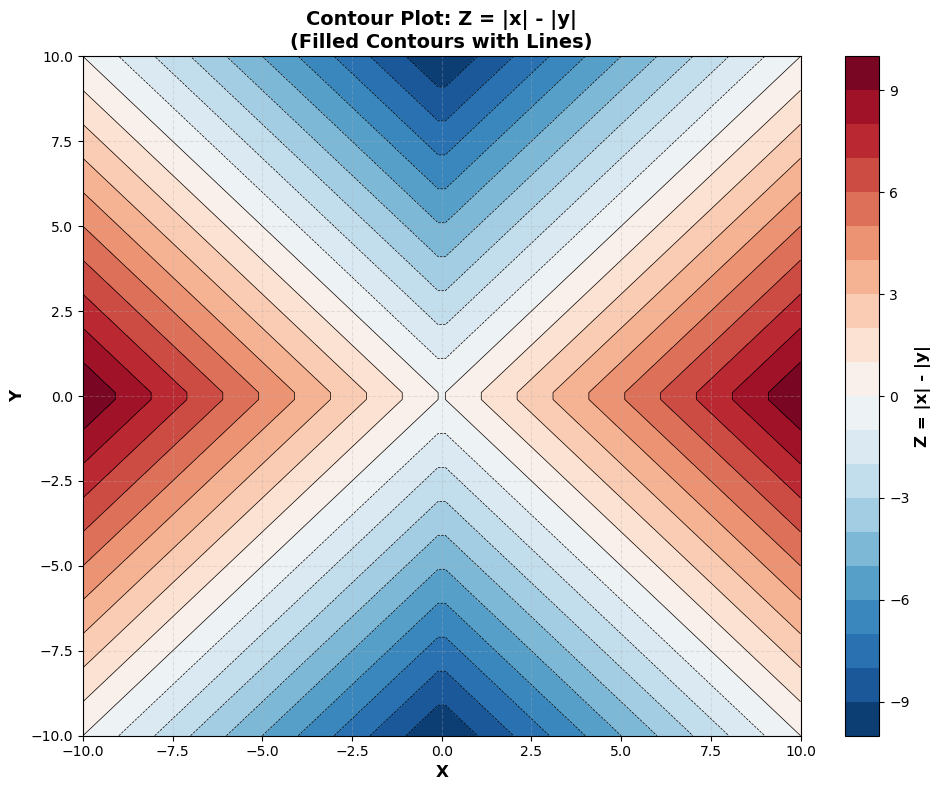

In [99]:
fig, ax = plt.subplots(figsize=(10, 8))

contourf = ax.contourf(X, Y, Z, levels=20, cmap='RdBu_r')

# Add contour lines on top
contour = ax.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5)

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label('Z = |x| - |y|', fontsize=12, fontweight='bold')

# Add labels and title
ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_title('Contour Plot: Z = |x| - |y|\n(Filled Contours with Lines)', 
             fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('contour_plot_abs.png', dpi=300, bbox_inches='tight')
plt.show()

## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

Top 5 stocks by turnover in 2020:
Symbol
RELIANCE      6.448526e+18
SBIN          4.390030e+18
ICICIBANK     3.989368e+18
TATAMOTORS    2.888231e+18
AXISBANK      2.877272e+18
Name: Turnover, dtype: float64


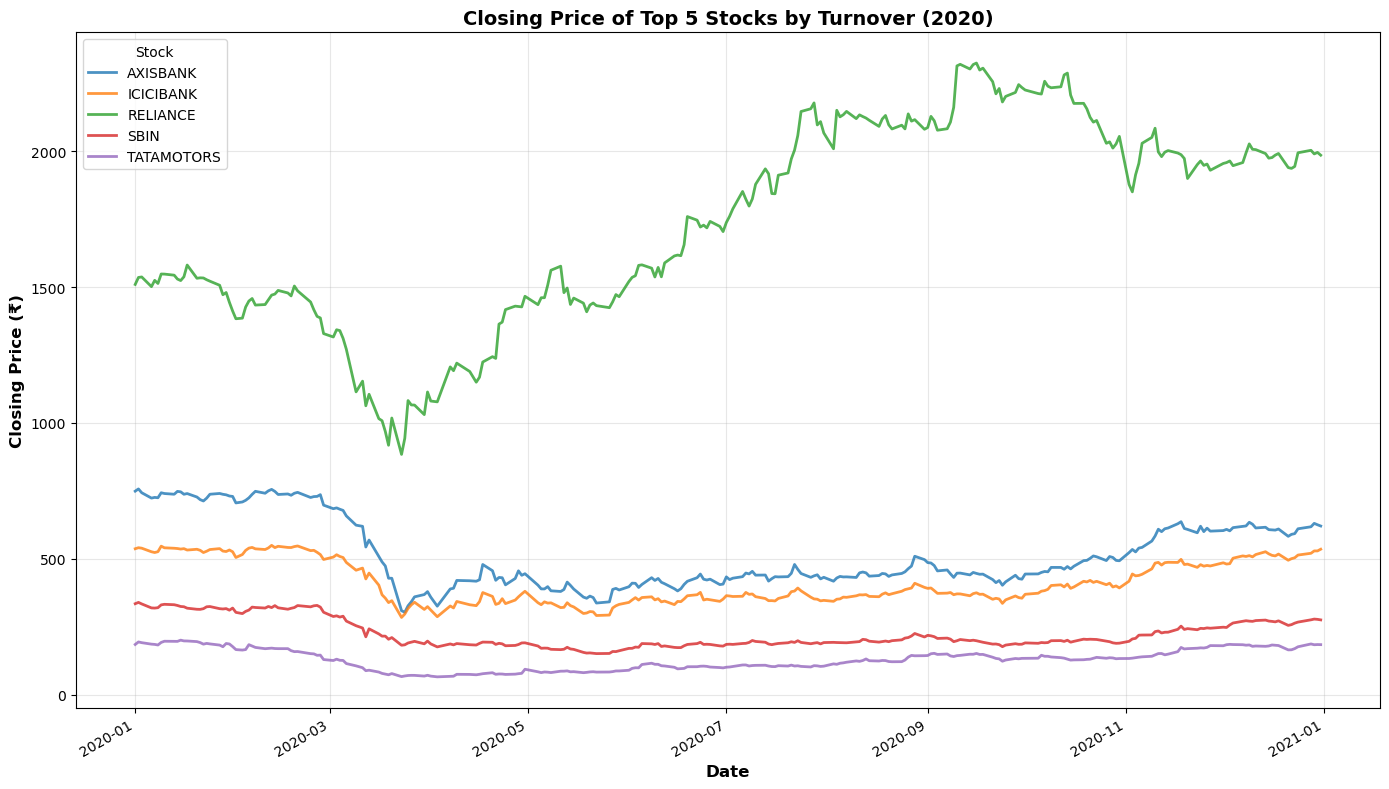

In [106]:
nifty50 = pd.read_csv('nifty-50 - nifty-50.csv')

# Calculate total turnover per stock in 2020
stock_turnover = nifty50.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False)
top5_stocks = stock_turnover.head(5).index.tolist()

print("Top 5 stocks by turnover in 2020:")
print(stock_turnover.head(5))

# Filter for top 5 stocks and 2020 data
nifty50['Date'] = pd.to_datetime(nifty50['Date'])
df_2020 = nifty50[nifty50['Date'].dt.year == 2020]
df_top5 = df_2020[df_2020['Symbol'].isin(top5_stocks)].copy().drop_duplicates()

# Create pivot table: Date as index, Stocks as columns, Close as values
pivot = df_top5.pivot(index='Date', columns='Symbol', values='Close')

# Plot using pandas plot function
fig, ax = plt.subplots(figsize=(14, 8))

pivot.plot(ax=ax,linewidth=2,alpha=0.8,grid=True,xlabel='Date',ylabel='Closing Price (₹)',fontsize=10)

ax.set_title('Closing Price of Top 5 Stocks by Turnover (2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Closing Price (₹)', fontsize=12, fontweight='bold')
ax.legend(title='Stock', loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stock_line_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

Top 5 stocks by turnover in 2021:
Symbol
TATAMOTORS    4.480973e+17
RELIANCE      3.550131e+17
SBIN          2.901291e+17
TATASTEEL     2.791109e+17
HDFCBANK      2.431887e+17
Name: Turnover, dtype: float64


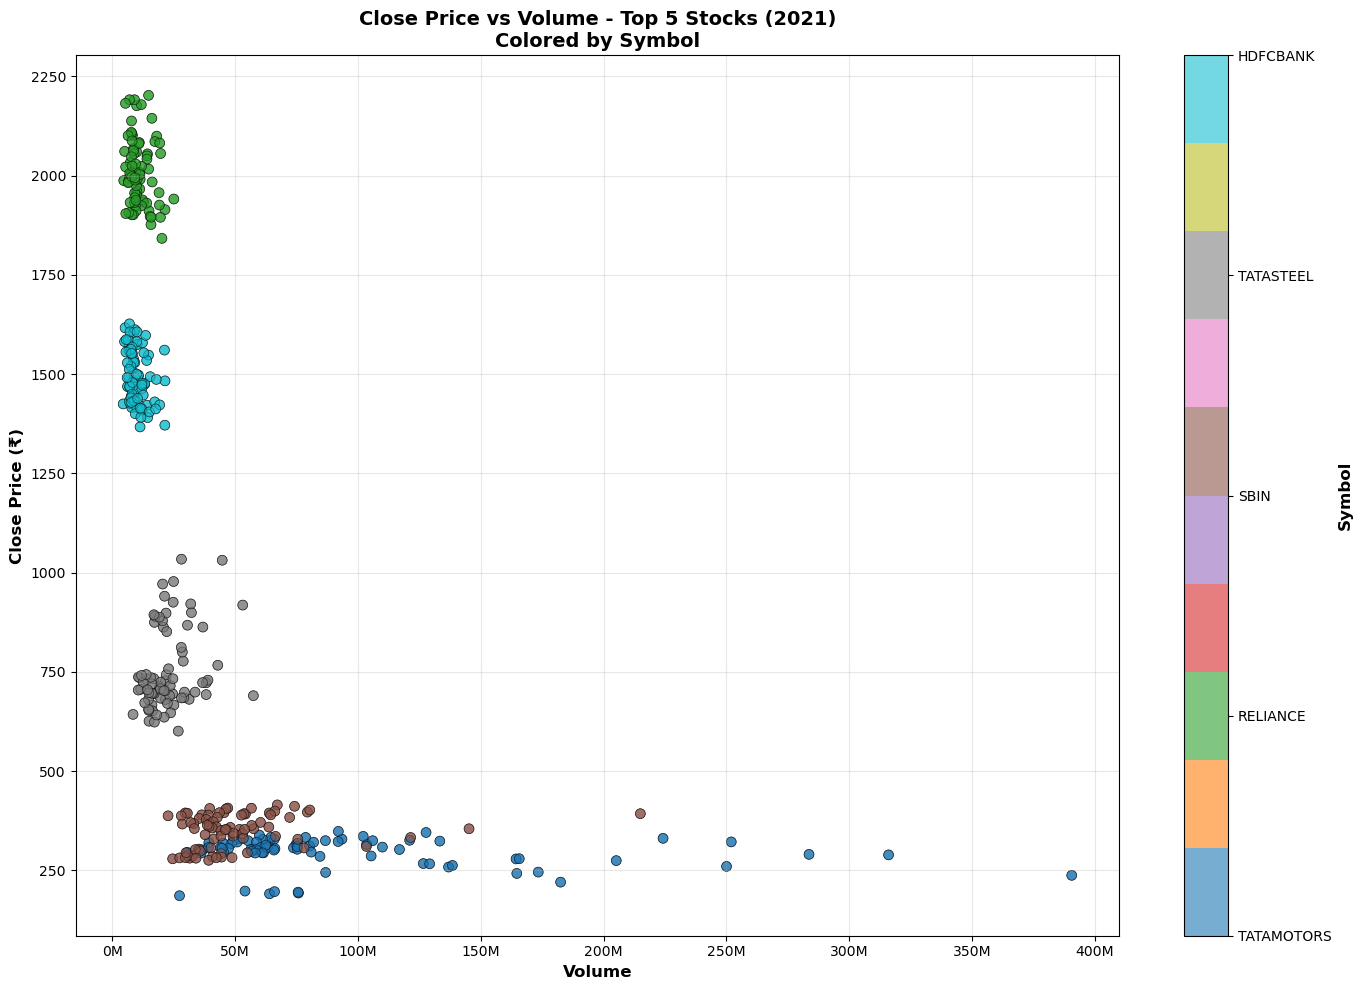

In [107]:

# Filter for 2021
nifty50['Date'] = pd.to_datetime(nifty50['Date'])
df_2021 = nifty50[nifty50['Date'].dt.year == 2021]

# Find top 5 stocks by turnover in 2021
stock_turnover = df_2021.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False)
top5 = stock_turnover.head(5).index.tolist()

print("Top 5 stocks by turnover in 2021:")
print(stock_turnover.head(5))

# Filter for top 5
df_top5 = df_2021[df_2021['Symbol'].isin(top5)].copy()

# Map symbols to numbers for color coding
symbol_map = {sym: i for i, sym in enumerate(top5)}
df_top5['symbol_code'] = df_top5['Symbol'].map(symbol_map)

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(df_top5['Volume'],df_top5['Close'],c=df_top5['symbol_code'],cmap='tab10',alpha=0.6,s=50,edgecolors='black',linewidth=0.5)

# Colorbar with stock names
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks(range(len(top5)))
cbar.set_ticklabels(top5)
cbar.set_label('Symbol', fontsize=12, fontweight='bold')

ax.set_xlabel('Volume', fontsize=12, fontweight='bold')
ax.set_ylabel('Close Price (₹)', fontsize=12, fontweight='bold')
ax.set_title('Close Price vs Volume - Top 5 Stocks (2021)\nColored by Symbol', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Format volume in millions
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('scatter_close_volume.png', dpi=300, bbox_inches='tight')
plt.show()

### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```

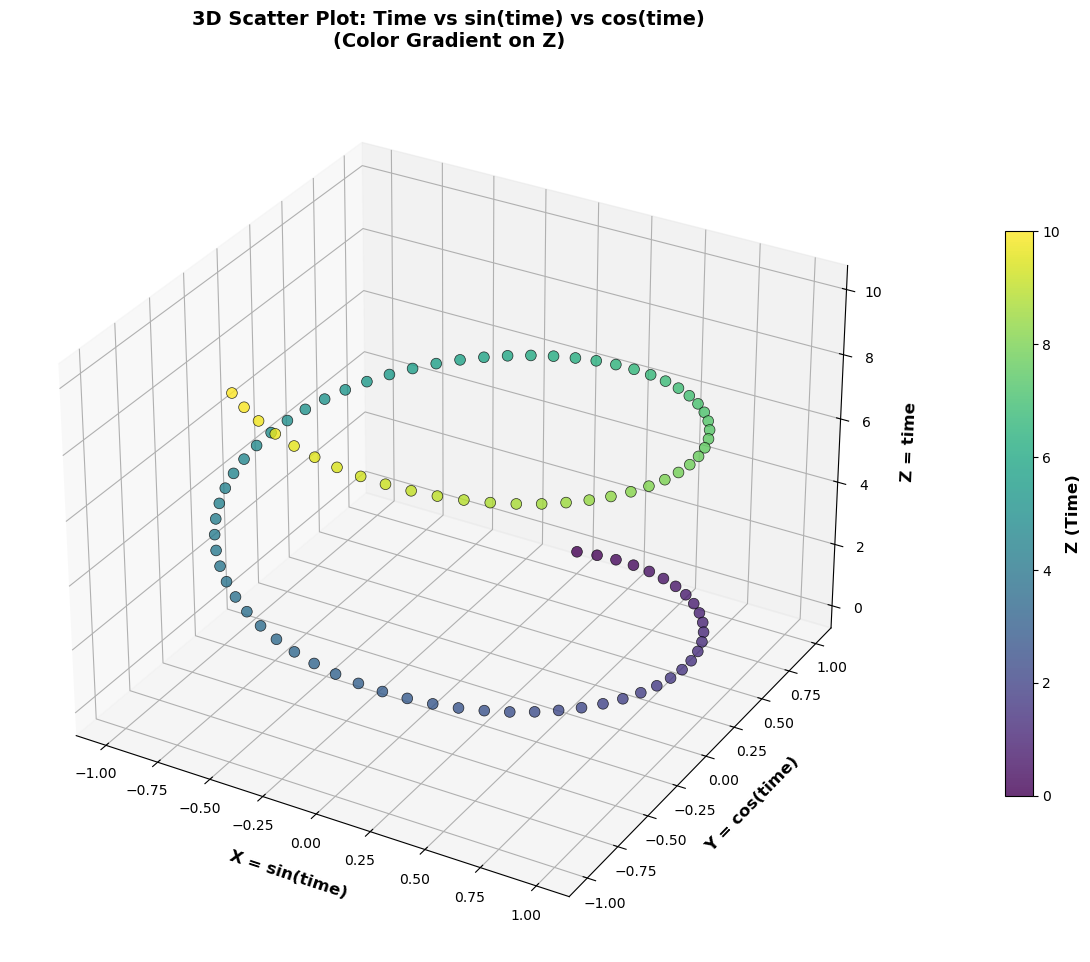

In [108]:

time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})

# Create 3D scatter plot with color gradient on z
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot - color gradient on z
scatter = ax.scatter(data['x'],data['y'],data['z'],c=data['z'],cmap='viridis',s=60,alpha=0.8,edgecolors='black',linewidth=0.5)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Z (Time)', fontsize=12, fontweight='bold')

ax.set_xlabel('X = sin(time)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Y = cos(time)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Z = time', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('3D Scatter Plot: Time vs sin(time) vs cos(time)\n(Color Gradient on Z)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3d_time_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

### `Problem 9:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = sin(\sqrt{x^2 + y^2})$$


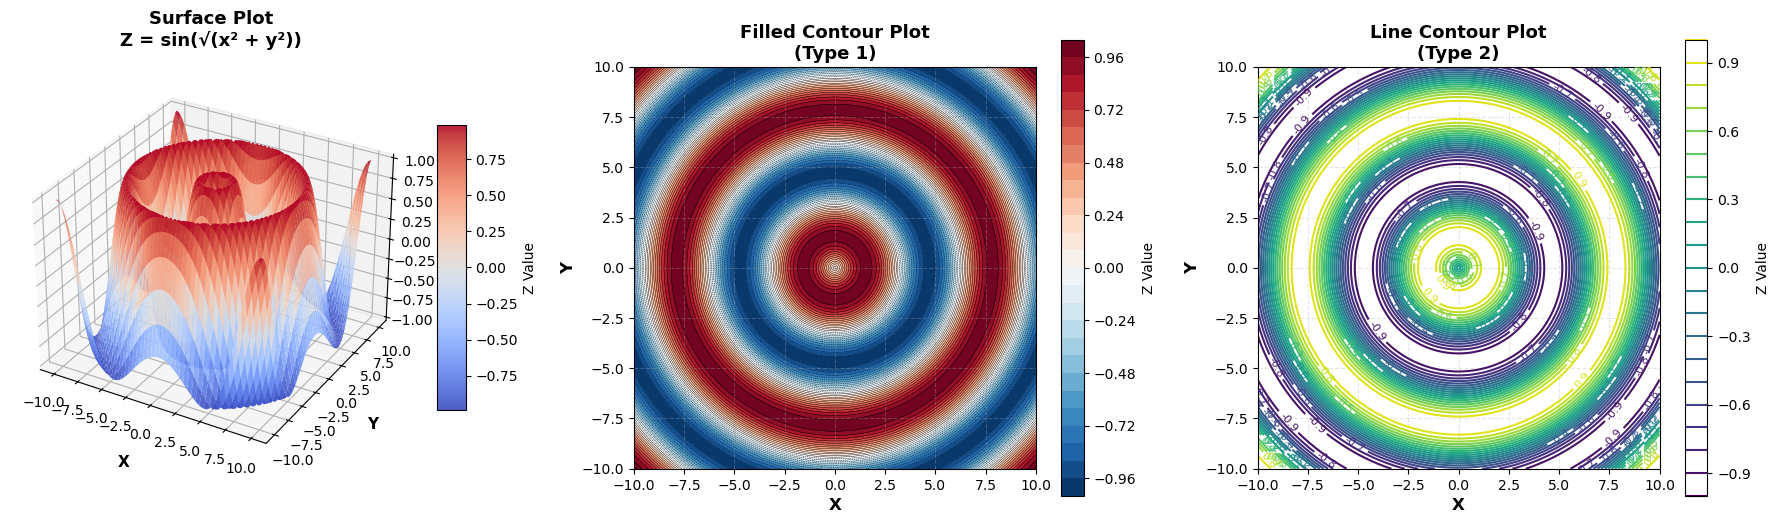

In [109]:
x = np.linspace(-10, 10, 200)
y = np.linspace(-10, 10, 200)
X, Y = np.meshgrid(x, y)

# Calculate Z = sin(sqrt(x^2 + y^2))
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

# Create figure with 3 subplots
fig = plt.figure(figsize=(18, 6))

# PLOT 1: Surface Plot
ax1 = fig.add_subplot(131, projection='3d')

surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.9, edgecolor='none', antialiased=True)

ax1.set_xlabel('X', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel('Y', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_zlabel('Z = sin(√(x²+y²))', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_title('Surface Plot\nZ = sin(√(x² + y²))', fontsize=13, fontweight='bold', pad=15)

fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Z Value')

# PLOT 2: Filled Contour Plot (Type 1)
ax2 = fig.add_subplot(132)

contourf = ax2.contourf(X, Y, Z, levels=30, cmap='RdBu_r')
ax2.contour(X, Y, Z, levels=30, colors='black', linewidths=0.3)

ax2.set_xlabel('X', fontsize=12, fontweight='bold')
ax2.set_ylabel('Y', fontsize=12, fontweight='bold')
ax2.set_title('Filled Contour Plot\n(Type 1)', fontsize=13, fontweight='bold')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3, linestyle='--')

fig.colorbar(contourf, ax=ax2, shrink=0.8, label='Z Value')

# PLOT 3: Line Contour Plot (Type 2)
ax3 = fig.add_subplot(133)

contour = ax3.contour(X, Y, Z, levels=20, cmap='viridis', linewidths=1.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

ax3.set_xlabel('X', fontsize=12, fontweight='bold')
ax3.set_ylabel('Y', fontsize=12, fontweight='bold')
ax3.set_title('Line Contour Plot\n(Type 2)', fontsize=13, fontweight='bold')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3, linestyle='--')

fig.colorbar(contour, ax=ax3, shrink=0.8, label='Z Value')

plt.tight_layout()
plt.savefig('surface_contour_plots.png', dpi=300, bbox_inches='tight')
plt.show()

### `Problem 10:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = tan(\log_2({x^2 + y^2})$$

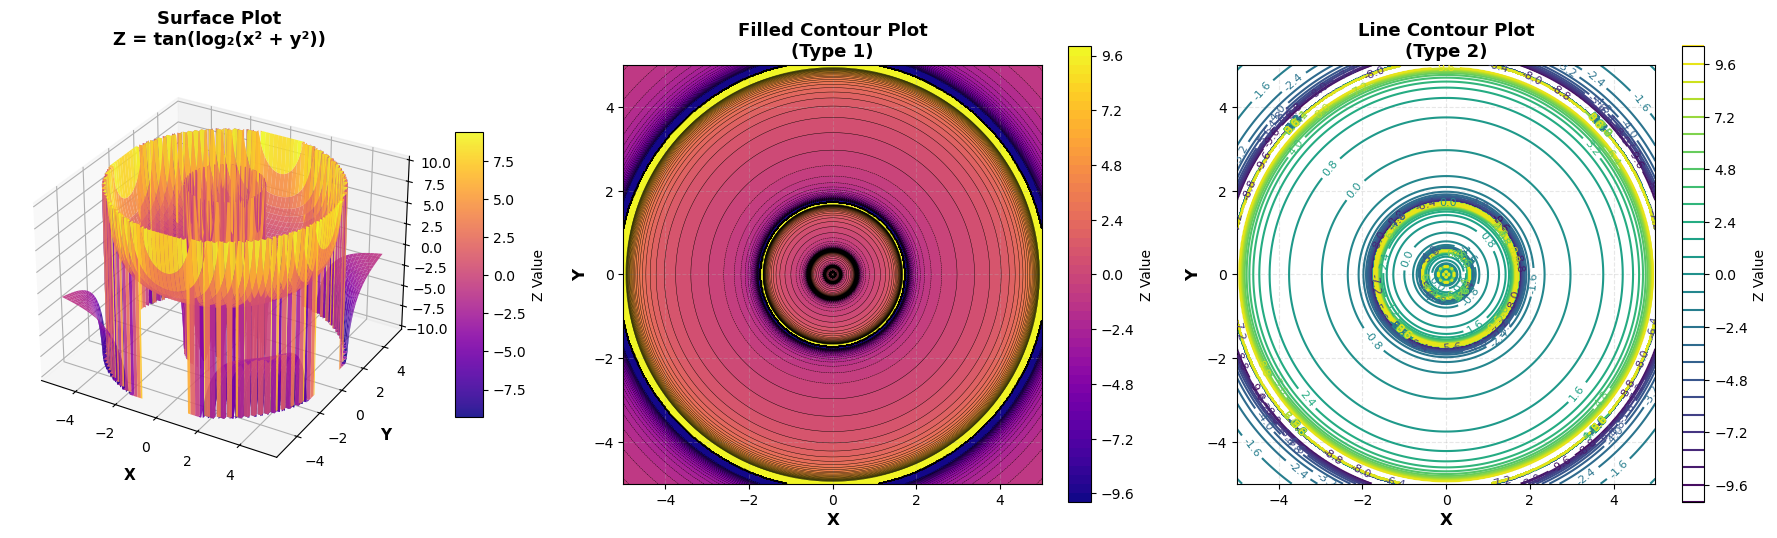

In [110]:
# Create grid - avoid singularity at origin
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)

# Calculate R^2 = x^2 + y^2 with safety for log(0)
R2 = X**2 + Y**2
epsilon = 1e-10
R2_safe = np.where(R2 < epsilon, epsilon, R2)

# Calculate Z = tan(log_2(x^2 + y^2))
log2_val = np.log(R2_safe) / np.log(2)
Z = np.tan(log2_val)

# Clip extreme values for visualization
Z_clipped = np.clip(Z, -10, 10)

# Create figure with 3 subplots
fig = plt.figure(figsize=(18, 6))

# PLOT 1: Surface Plot
ax1 = fig.add_subplot(131, projection='3d')

surf = ax1.plot_surface(X, Y, Z_clipped, cmap='plasma', alpha=0.9, edgecolor='none', antialiased=True)

ax1.set_xlabel('X', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel('Y', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_zlabel('Z = tan(log₂(x²+y²))', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_title('Surface Plot\nZ = tan(log₂(x² + y²))', fontsize=13, fontweight='bold', pad=15)

fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Z Value')

# PLOT 2: Filled Contour Plot (Type 1)
ax2 = fig.add_subplot(132)

contourf = ax2.contourf(X, Y, Z_clipped, levels=50, cmap='plasma')
ax2.contour(X, Y, Z_clipped, levels=50, colors='black', linewidths=0.3)

ax2.set_xlabel('X', fontsize=12, fontweight='bold')
ax2.set_ylabel('Y', fontsize=12, fontweight='bold')
ax2.set_title('Filled Contour Plot\n(Type 1)', fontsize=13, fontweight='bold')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3, linestyle='--')

fig.colorbar(contourf, ax=ax2, shrink=0.8, label='Z Value')

# PLOT 3: Line Contour Plot (Type 2)
ax3 = fig.add_subplot(133)

contour = ax3.contour(X, Y, Z_clipped, levels=30, cmap='viridis', linewidths=1.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

ax3.set_xlabel('X', fontsize=12, fontweight='bold')
ax3.set_ylabel('Y', fontsize=12, fontweight='bold')
ax3.set_title('Line Contour Plot\n(Type 2)', fontsize=13, fontweight='bold')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3, linestyle='--')

fig.colorbar(contour, ax=ax3, shrink=0.8, label='Z Value')

plt.tight_layout()
plt.savefig('surface_contour_tan_log.png', dpi=300, bbox_inches='tight')
plt.show()